Import Libraries

In [3]:
# Deep Learning Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM

from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
# Load dataset (TXT files)

import pandas as pd

X_train = pd.read_csv("X_train.txt", delim_whitespace=True)
y_train = pd.read_csv("y_train.txt", header=None)
y_test = pd.read_csv("y_test.txt", header=None)

print("Data loaded successfully")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

/tmp/ipykernel_2897/3367965836.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv("X_train.txt", delim_whitespace=True)


Data loaded successfully
X_train shape: (7351, 561)
y_train shape: (7352, 1)
y_test shape: (2947, 1)


In [7]:
# Load dataset (TXT files)

import pandas as pd

X_train = pd.read_csv("X_train.txt", delim_whitespace=True)
X_test = pd.read_csv("X_test.txt", delim_whitespace=True)

y_train = pd.read_csv("y_train.txt", header=None)
y_test = pd.read_csv("y_test.txt", header=None)

print("Data loaded successfully")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

/tmp/ipykernel_2897/2808477141.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv("X_train.txt", delim_whitespace=True)
/tmp/ipykernel_2897/2808477141.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv("X_test.txt", delim_whitespace=True)


Data loaded successfully
X_train shape: (7351, 561)
X_test shape: (2946, 561)
y_train shape: (7352, 1)
y_test shape: (2947, 1)


In [8]:
# Reshape data for Deep Learning

import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

# Reshape to 3D
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaping done")

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

Reshaping done
New X_train shape: (7351, 561, 1)
New X_test shape: (2946, 561, 1)


**Deep Learning Implementation**








Data Reshaping for deep learning

In [9]:
# Data Reshaping for Deep Learning

import numpy as np

# Convert to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

# Reshape data into 3D format
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaping completed")

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

Reshaping completed
New X_train shape: (7351, 561, 1)
New X_test shape: (2946, 561, 1)


**Train and Evaluate CNN Model**

In [10]:
# Build CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

cnn_model = Sequential()

cnn_model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train.shape[1], 1)
))

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Dropout(0.3))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dense(6, activation='softmax'))

print("CNN model created successfully")

CNN model created successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile CNN Model

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully")

CNN model compiled successfully


In [16]:
# Train CNN Model

history_cnn = cnn_model.fit(
    X_train,
    y_train - 1,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9629 - loss: 0.1015 - val_accuracy: 0.9096 - val_loss: 0.2752
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9665 - loss: 0.0889 - val_accuracy: 0.9184 - val_loss: 0.2519
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9733 - loss: 0.0746 - val_accuracy: 0.9273 - val_loss: 0.2339
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9673 - loss: 0.0855 - val_accuracy: 0.9211 - val_loss: 0.2483
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9680 - loss: 0.0769 - val_accuracy: 0.9123 - val_loss: 0.2706
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9753 - loss: 0.0652 - val_accuracy: 0.9177 - val_loss: 0.2887
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9796 - loss: 0.0544 - val_accuracy: 0.9239 - val_loss: 0.2664
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9799 - loss: 0.0514 - val_

In [13]:
# Fix mismatch between X_test and y_test

min_samples = min(len(X_test), len(y_test))

X_test = X_test[:min_samples]
y_test = y_test[:min_samples]

print("After fixing:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

After fixing:
X_test shape: (2946, 561, 1)
y_test shape: (2946, 1)


In [17]:
# Evaluate CNN Model

loss_cnn, accuracy_cnn = cnn_model.evaluate(
    X_test,
    y_test - 1
)

print("CNN Test Loss:", loss_cnn)
print("CNN Test Accuracy:", accuracy_cnn)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8948 - loss: 0.4112
CNN Test Loss: 0.41122666001319885
CNN Test Accuracy: 0.8947725892066956


In [ ]:
# Classification Report for CNN

from sklearn.metrics import classification_report
import numpy as np

# Predict probabilities
y_pred = cnn_model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Activity names
activity_labels = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Generate report
report = classification_report(
    y_test - 1,
    y_pred_classes,
    target_names=activity_labels
)

print(report)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
                    precision    recall  f1-score   support

           WALKING       0.92      0.96      0.94       496
  WALKING_UPSTAIRS       0.89      0.85      0.87       470
WALKING_DOWNSTAIRS       0.86      0.90      0.88       420
           SITTING       0.96      0.82      0.89       491
          STANDING       0.86      0.95      0.90       532
            LAYING       0.97      0.96      0.97       537

          accuracy                           0.91      2946
         macro avg       0.91      0.91      0.91      2946
      weighted avg       0.91      0.91      0.91      2946



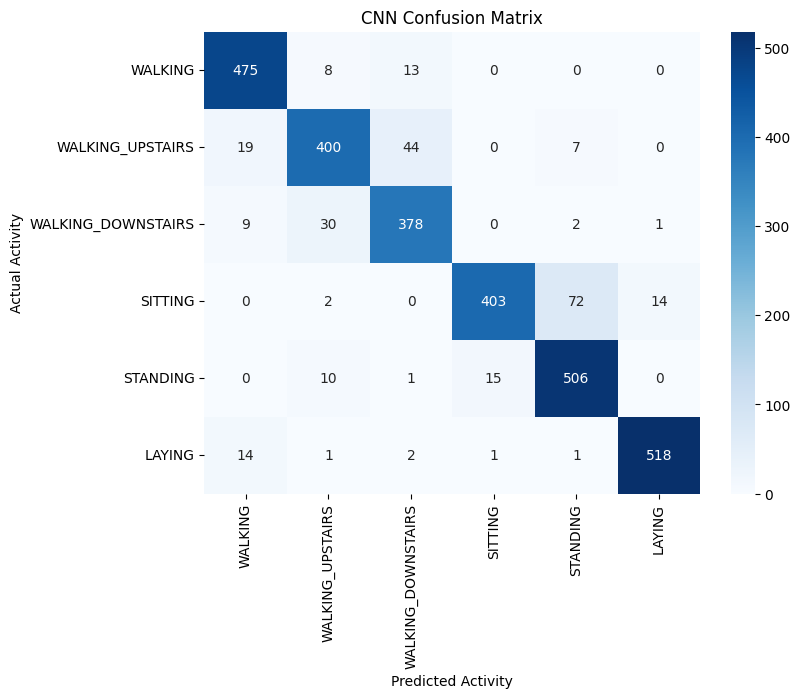

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test - 1,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.show()

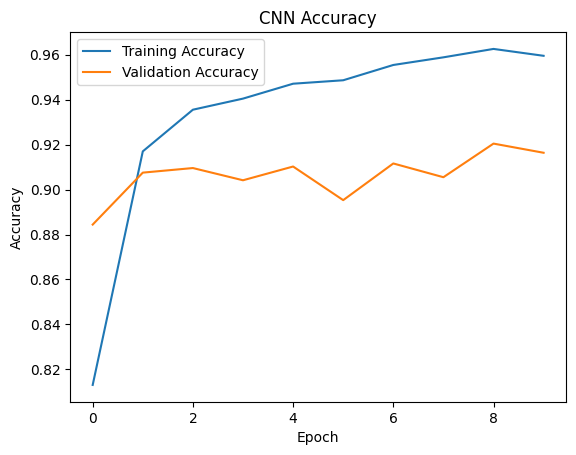

In [15]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

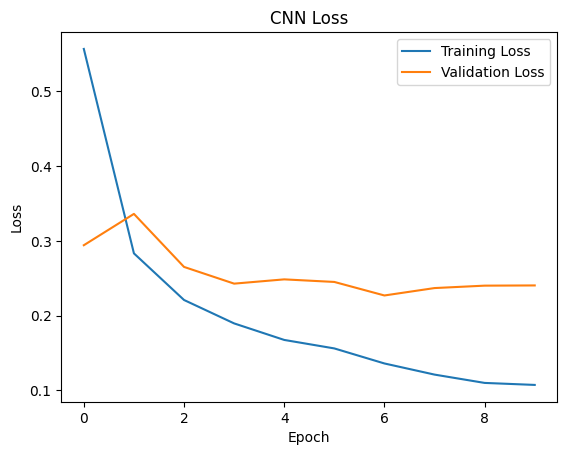

In [ ]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

**Train and Evaluate LSTM Model**

In [18]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Build LSTM model

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(64, activation='relu'))

lstm_model.add(Dense(6, activation='softmax'))

# Compile model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,446 (83.77 KB)

 Trainable params: 21,446 (83.77 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Fix mismatch between X_train and y_train

min_samples = min(len(X_train), len(y_train))

X_train = X_train[:min_samples]
y_train = y_train[:min_samples]

print("After fixing:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

After fixing:
X_train shape: (7351, 561, 1)
y_train shape: (7351, 1)


In [22]:
## Train lstm model
history_lstm = lstm_model.fit(

    X_train,
    y_train - 1,

    epochs=10,
    batch_size=32,

    validation_data=(
        X_test,
        y_test - 1
    )
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 42s 183ms/step - accuracy: 0.6905 - loss: 0.7185 - val_accuracy: 0.7247 - val_loss: 0.6966
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 80s 173ms/step - accuracy: 0.7092 - loss: 0.6898 - val_accuracy: 0.7729 - val_loss: 0.6299
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.7361 - loss: 0.6529 - val_accuracy: 0.7705 - val_loss: 0.6177
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 175ms/step - accuracy: 0.7511 - loss: 0.6410 - val_accuracy: 0.7695 - val_loss: 0.6153
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/step - accuracy: 0.7645 - loss: 0.6051 - val_accuracy: 0.7878 - val_loss: 0.5640
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.7698 - loss: 0.5910 - val_accuracy: 0.8116 - val_loss: 0.5156
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - accuracy: 0.7796 - loss: 0.5761 - val_accuracy: 0.7990 - val_loss: 0.5323
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step - accuracy: 0.7859 - loss: 0

In [23]:
## Evaluate lstm model
loss_lstm, accuracy_lstm = lstm_model.evaluate(
    X_test,
    y_test - 1
)

print("LSTM Test Loss:", loss_lstm)
print("LSTM Test Accuracy:", accuracy_lstm)

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8075 - loss: 0.5063
LSTM Test Loss: 0.5063098073005676
LSTM Test Accuracy: 0.8075356483459473


In [24]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = lstm_model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

activity_labels = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print(
    classification_report(
        y_test - 1,
        y_pred_classes,
        target_names=activity_labels
    )
)

93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step
                    precision    recall  f1-score   support

           WALKING       0.74      0.91      0.81       496
  WALKING_UPSTAIRS       0.74      0.76      0.75       470
WALKING_DOWNSTAIRS       0.89      0.66      0.76       420
           SITTING       0.88      0.59      0.71       491
          STANDING       0.72      0.92      0.81       532
            LAYING       0.96      0.96      0.96       537

          accuracy                           0.81      2946
         macro avg       0.82      0.80      0.80      2946
      weighted avg       0.82      0.81      0.80      2946



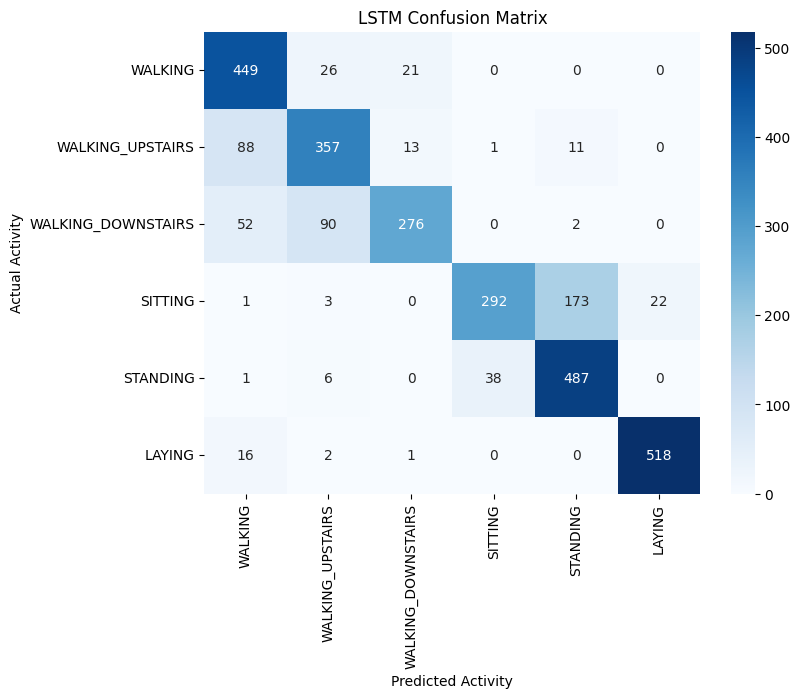

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test - 1,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.show()

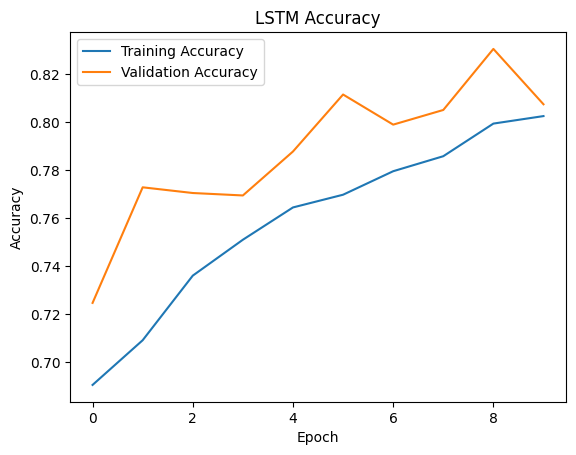

In [27]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

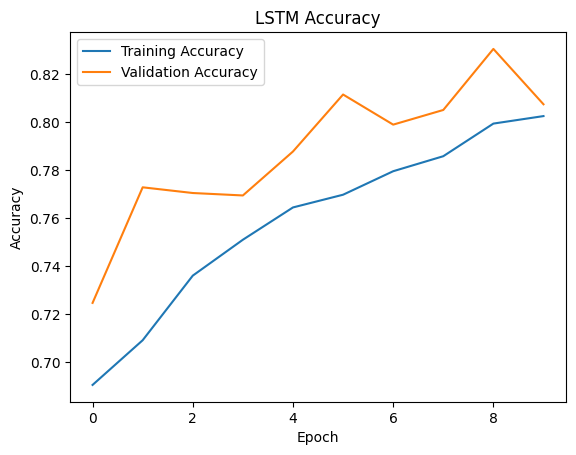

In [28]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

**Model Comparison**

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Your actual accuracy values

cnn_accuracy = 0.894
lstm_accuracy = 0.807

model_names = [
    "CNN",
    "LSTM"
]

accuracies = [
    cnn_accuracy,
    lstm_accuracy
]

# Create comparison table

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print(comparison_df)

  Model  Accuracy
0   CNN     0.894
1  LSTM     0.807


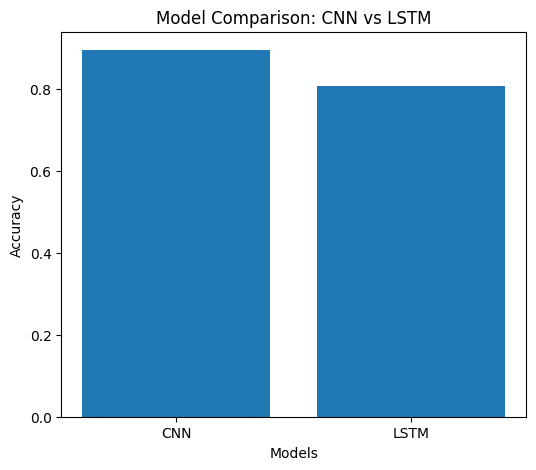

In [32]:
plt.figure(figsize=(6,5))

plt.bar(
    model_names,
    accuracies
)

plt.title("Model Comparison: CNN vs LSTM")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()